In [62]:
import os
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_ionq import IonQProvider

In [63]:

X = np.linspace(0, 2*np.pi, 20)
X.requires_grad = False
X_test = np.linspace(0.2, 2*np.pi + 0.2, 20)

In [110]:
rng = np.random.default_rng(42)


def target(x, sigma_phase=0.1):
    dx1 = rng.normal(0, sigma_phase, size=np.shape(x))
    dx2 = rng.normal(0, sigma_phase, size=np.shape(x))
    return 0.5*np.sin(x + dx1) + 0.5*np.sin(2*x + dx2)


In [111]:

# Noisy simulator device

dev = qml.device('lightning.qubit', wires=1)

@qml.qnode(dev)
def circuit(x, params):
    for k in range(params.shape[0]):
        qml.RY(x, wires=0)
        qml.Rot(params[k, 0], params[k, 1], params[k, 2], wires=0)
    return qml.expval(qml.PauliX(0))

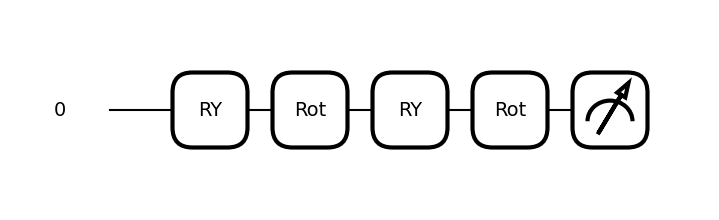

In [112]:
# Draw it
qml.draw_mpl(circuit)(0.0, np.array([[0.0, 0.0, 0.0],
                                     [0.0, 0.0, 0.0]]))
plt.show()

In [113]:
# -----------------------------
# Loss / cost (use MSE)
# -----------------------------
def loss(y, yhat):
    return np.mean((y - yhat) ** 2)

def cost(X, params):
    preds = np.array([circuit(x, params) for x in X])
    Y = target(X)
    return loss(Y, preds)

In [114]:
n_iter = 69
opt = qml.GradientDescentOptimizer(stepsize=0.1)
params = np.array(
        [[0.1, 0.1, 0.1],
         [0.1, 0.1, 0.1]],
        requires_grad=True)

In [115]:
for it in range(n_iter):
  X_and_params, prev_cost = opt.step_and_cost(cost, X , params)
  params = X_and_params[1]
  if it%10==0:
    print(f'Step: {it}, Cost:{cost(X, params)}')


Step: 0, Cost:0.25223306734438006
Step: 10, Cost:0.23585206519827556
Step: 20, Cost:0.0995211113785566
Step: 30, Cost:0.004718701521894372
Step: 40, Cost:0.003092294932271836
Step: 50, Cost:0.0023746328966461616
Step: 60, Cost:0.002671665192501717


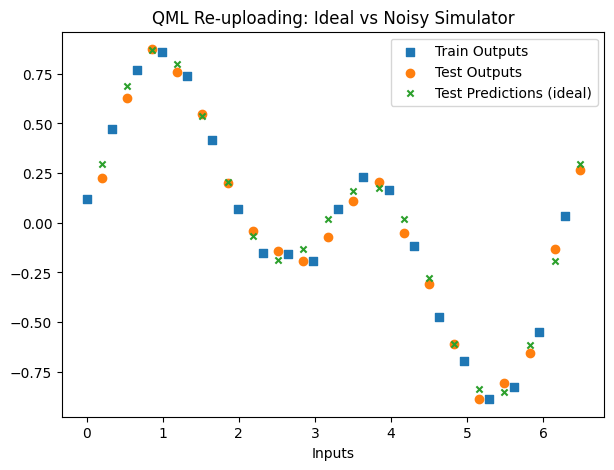

In [116]:
# -----------------------------
# Test + plot (ideal + noisy)
# -----------------------------

# params from ideal simulator (already used above)
params_ideal = params

# other set of params (noisy simulator)
params_noisy = np.array([
    [-0.32160093894265800,  0.0016526396422344600, -0.3226805876206440],
    [ 0.4927960823253820, -0.0033553148388572800,  0.4940698506687130]
])

# predictions
test_predictions_ideal = np.array([circuit(x, params_ideal) for x in X_test])
test_predictions_noisy = np.array([circuit(x, params_noisy) for x in X_test])

# plot
plt.figure(figsize=(7, 5))
plt.scatter(X, target(X), marker="s", label="Train Outputs")
#plt.plot(X, target(X), color='blue')

plt.scatter(X_test, target(X_test), marker="o", label="Test Outputs")
#plt.plot(X_test, target(X_test), c= 'orange')

plt.scatter(X_test, test_predictions_ideal, s=20, marker="x", label="Test Predictions (ideal)")
#plt.plot(X_test, test_predictions_ideal)
#plt.scatter(X_test, test_predictions_noisy, s=10, marker="^", c='k', label="Test Predictions (noisy)")

plt.xlabel("Inputs")
plt.title("QML Re-uploading: Ideal vs Noisy Simulator")
plt.legend()
plt.show()
